# Introduction
This file will be for creating a Yolo Car recognition model that will be used to detect cars in an input image or video.

# 1. Import Libraries
Libraries that will be used in this file:
1. Ultralytics (Yolov11).
2. Torch.
3. OpenCV.
4. Numpy.
5. Matplotlib.

In [6]:
from ultralytics import YOLO
import torch
import cv2
import numpy as np
import os
import sys
import matplotlib.pyplot as plt

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [8]:
from modules.image_operations import get_img_paths, visualize_imgs

# 2. Load & Test Yolo Model
In this section, we will simply load the YOLO model and run quick test inference on random road images.

In [12]:
# YOlO Model + Images Folder
car_recog_model = YOLO("yolo11m.pt")
test_imgs_folder = r"G:\Work Projects\AI & ML Projects\AI-ML-Projects\Car Recognition & Classification\Car Object Recognition\Model Test Images"

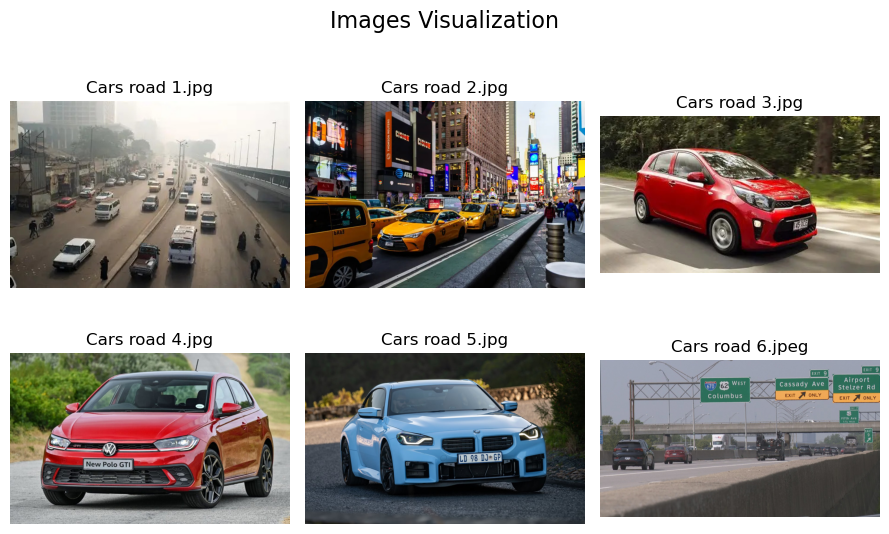

In [13]:
visualize_imgs(test_imgs_folder)

## 2.1. Inference Functions and Results

In [ ]:
def run_inference_batch_images(model, output_dir, imgs, visualize=False):
    """
    Run inference on a batch of images using a YOLOv11 model.

    Args:
        model (YOLOv11): The YOLOv11 model to use for inference.
        imgs (list): A list of image paths.

    Returns:
        results (list): A list of YOLOv11 inference results for each image.
    """

    # Create output directory
    output_dir = output_dir
    os.makedirs(output_dir, exist_ok=True)

    # Cars class for COCO
    cars = 2

    # Run inference
    detections = model(imgs)
    
    for img_path, detection in zip(imgs, detections):
        img = cv2.imread(img_path) # Read input image

        # Check if nothing was detected
        if detection.boxes is None:
            continue

        # Get Bounding Boxes
        for box in detection.boxes.data.tolist():
            x1, y1, x2, y2, score, class_id = box
            if class_id == cars:
                x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
                cv2.putText(img, f"Car: {round(score, 2)}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
                
        # Save output image
        output_path = os.path.join(output_dir, os.path.basename(img_path))
        cv2.imwrite(output_path, img)
    
    # Visualize images if required
    if visualize:
        visualize_imgs(output_dir)


0: 640x640 8 persons, 1 bicycle, 19 cars, 1 motorcycle, 1 bus, 3 trucks, 13.8ms
1: 640x640 8 persons, 10 cars, 1 truck, 13.8ms
2: 640x640 1 car, 13.8ms
3: 640x640 1 car, 13.8ms
4: 640x640 1 person, 1 car, 13.8ms
5: 640x640 10 cars, 3 trucks, 13.8ms
Speed: 5.9ms preprocess, 13.8ms inference, 18.7ms postprocess per image at shape (1, 3, 640, 640)


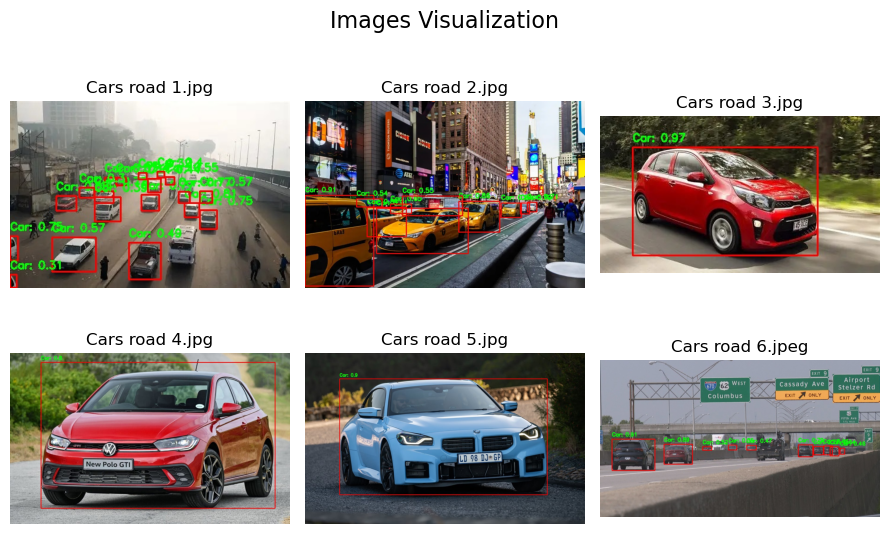

In [16]:
# Test function
run_inference_batch_images(car_recog_model, "inference images", imgs=get_img_paths(test_imgs_folder), visualize=True)